<a href="https://colab.research.google.com/github/selim679/D-tection-Automatique-de-Fissures-sur-B-ton/blob/main/projet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
#  CELLULE 1 — Installation des dépendances
# ============================================================
!pip install -q kaggle albumentations opencv-python-headless tensorflow==2.15

import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB3
import albumentations as A
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
import seaborn as sns

print("GPU :", tf.config.list_physical_devices('GPU'))

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
#  CELLULE 2 — Téléchargement Kaggle API
# ============================================================
# 1. Uploadez votre fichier kaggle.json via : files.upload()
from google.colab import files
files.upload()  # sélectionnez kaggle.json

os.makedirs('/root/.config/kaggle', exist_ok=True)
!cp kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json

# 2. Téléchargement direct dans /content/ (pas de Drive)
!kaggle datasets download -d arunrk7/surface-crack-detection \
    --path /content/crack_data --unzip

# Structure attendue :
# /content/crack_data/Positive/  → images avec fissures
# /content/crack_data/Negative/  → images sans fissures

DATA_DIR    = '/content/crack_data'
POS_DIR     = os.path.join(DATA_DIR, 'Positive')
NEG_DIR     = os.path.join(DATA_DIR, 'Negative')
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

print(f"Positive : {len(os.listdir(POS_DIR))} images")
print(f"Negative : {len(os.listdir(NEG_DIR))} images")

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
100% 233M/233M [00:01<00:00, 183MB/s]

Positive : 20000 images
Negative : 20000 images


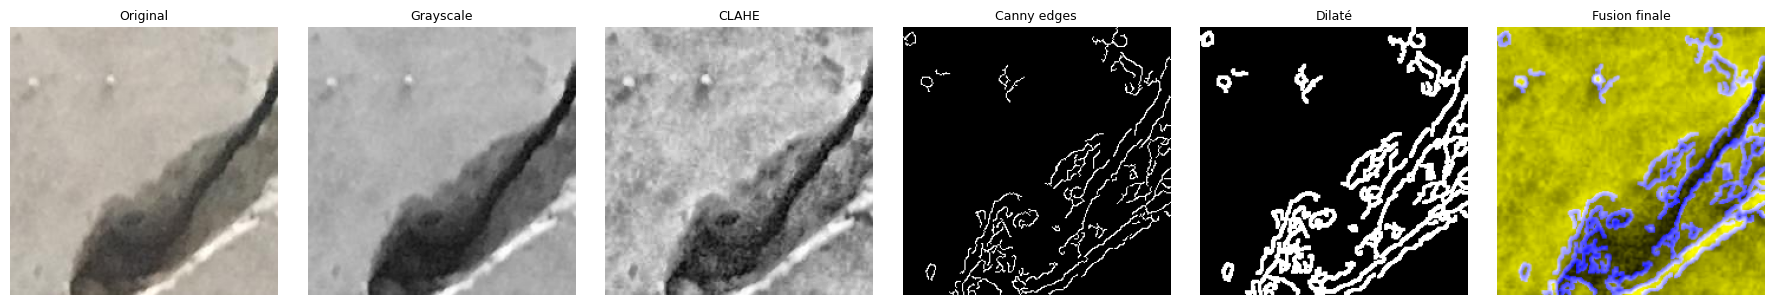

In [4]:
# ============================================================
#  CELLULE 3 — Pipeline de prétraitement OpenCV
# ============================================================
def preprocess_opencv(img_bgr: np.ndarray) -> np.ndarray:
    """
    Pipeline OpenCV optimisé pour la détection de fissures.

    Justifications :
    ─────────────────────────────────────────────────────────
    1. Grayscale : les fissures sont des structures de forme,
       pas de couleur. Réduire à 1 canal élimine le bruit
       chromatique et simplifie les calculs.

    2. CLAHE (Contrast Limited Adaptive Histogram Equalization) :
       Contrairement à l'égalisation globale, CLAHE opère sur
       des tuiles locales (tileGridSize=8×8) et limite
       l'amplification du bruit (clipLimit=3.0). Résultat :
       les fissures peu contrastées deviennent visibles même
       sur des surfaces hétérogènes.

    3. Flou Gaussien (5×5) : atténue le bruit haute fréquence
       avant la détection de contours, réduisant les faux
       positifs de Canny.

    4. Détection de contours Canny : extrait les bords forts
       (structures de fissures) en supprimant le fond uniforme.
       Seuils calibrés empiriquement pour ce dataset.

    5. Dilatation morphologique (3×3) : épaissit les contours
       détectés pour renforcer la connectivité des fissures
       fragmentées. Compense la discontinuité de Canny.

    6. Fusion canal-image originale : le canal original (CLAHE)
       apporte la texture, le canal Canny+dilatation apporte
       la structure. L'image résultante RGB synthétique
       encode les deux types d'information.
    ─────────────────────────────────────────────────────────
    """
    # 1. Niveaux de gris
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. CLAHE — amélioration adaptive du contraste local
    clahe  = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # 3. Réduction du bruit
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # 4. Détection de contours Canny
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

    # 5. Opération morphologique — dilatation pour connecter les fissures
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(edges, kernel, iterations=1)

    # 6. Construction d'une image RGB synthétique 3 canaux
    #    Canal R : image CLAHE (texture globale)
    #    Canal G : image CLAHE (information colorimétrique neutre)
    #    Canal B : contours dilates (structure des fissures)
    fused = cv2.merge([enhanced, enhanced, dilated])

    # Redimensionnement final
    resized = cv2.resize(fused, (IMG_SIZE, IMG_SIZE))
    return resized


def visualize_preprocessing(img_path: str):
    """Affiche les étapes intermédiaires du pipeline."""
    img     = cv2.imread(img_path)
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enh     = clahe.apply(gray)
    blur    = cv2.GaussianBlur(enh, (5, 5), 0)
    edges   = cv2.Canny(blur, 50, 150)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(edges, kernel, iterations=1)
    fused   = cv2.merge([enh, enh, dilated])

    titles = ['Original', 'Grayscale', 'CLAHE', 'Canny edges', 'Dilaté', 'Fusion finale']
    imgs   = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), gray, enh, edges, dilated,
              cv2.resize(fused, (IMG_SIZE, IMG_SIZE))]
    cmaps  = ['viridis'] + ['gray'] * 4 + ['viridis']

    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for ax, title, im, cm in zip(axes, titles, imgs, cmaps):
        ax.imshow(im, cmap=cm)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Test sur une image positive
sample = os.path.join(POS_DIR, os.listdir(POS_DIR)[0])
visualize_preprocessing(sample)

In [5]:
# ============================================================
#  CELLULE 4 — Construction du dataset tf.data
# ============================================================

# ── 4.1  Pipeline d'augmentation Albumentations ──────────────
# Stratégie : couvrir toutes les transformations plausibles
# en inspection de surfaces (rotation, éclairage, bruit, zoom)
# sans déformer les fissures (pas d'elastic invraisemblable).

aug_train = A.Compose([
    # Géométrie
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                       rotate_limit=30, p=0.6),
    A.RandomCrop(height=200, width=200, p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Photométrique
    A.RandomBrightnessContrast(brightness_limit=0.3,
                                contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=20, p=0.4),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.3),

    # Bruit & blur
    A.GaussNoise(var_limit=(10, 50), p=0.4),
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),

    # Occlusion partielle
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20,
                    fill_value=0, p=0.3),

    # Normalisation finale
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

aug_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


# ── 4.2  Chargement des chemins + labels ─────────────────────
def load_paths_labels(pos_dir, neg_dir):
    pos_paths = [(p, 1) for p in
                 [os.path.join(pos_dir, f) for f in os.listdir(pos_dir)]]
    neg_paths = [(p, 0) for p in
                 [os.path.join(neg_dir, f) for f in os.listdir(neg_dir)]]
    all_data  = pos_paths + neg_paths
    np.random.seed(SEED)
    np.random.shuffle(all_data)
    paths  = [x[0] for x in all_data]
    labels = [x[1] for x in all_data]
    return paths, labels

paths, labels = load_paths_labels(POS_DIR, NEG_DIR)

# Split 70 / 15 / 15
n = len(paths)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_p, train_l = paths[:n_train],        labels[:n_train]
val_p,   val_l   = paths[n_train:n_train+n_val], labels[n_train:n_train+n_val]
test_p,  test_l  = paths[n_train+n_val:],  labels[n_train+n_val:]

print(f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")


# ── 4.3  Fonction de chargement + prétraitement ──────────────
def load_and_preprocess(path: str, label: int, augment: bool = False):
    img_bgr  = cv2.imread(path.decode())
    img_proc = preprocess_opencv(img_bgr)          # Pipeline OpenCV

    if augment:
        aug      = aug_train(image=img_proc)
        img_proc = aug['image']
    else:
        aug      = aug_val(image=img_proc)
        img_proc = aug['image']

    return img_proc.astype(np.float32), np.float32(label)


def tf_load(path, label, augment):
    img, lbl = tf.numpy_function(
        lambda p, l: load_and_preprocess(p, l, augment),
        [path, label], [tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([])
    return img, lbl


# ── 4.4  Création des datasets tf.data ───────────────────────
AUTO = tf.data.AUTOTUNE

ds_train = (tf.data.Dataset.from_tensor_slices((train_p, train_l))
            .shuffle(len(train_p), seed=SEED)
            .map(lambda p, l: tf_load(p, l, True),  num_parallel_calls=AUTO)
            .batch(BATCH_SIZE)
            .prefetch(AUTO))

ds_val   = (tf.data.Dataset.from_tensor_slices((val_p, val_l))
            .map(lambda p, l: tf_load(p, l, False), num_parallel_calls=AUTO)
            .batch(BATCH_SIZE)
            .prefetch(AUTO))

ds_test  = (tf.data.Dataset.from_tensor_slices((test_p, test_l))
            .map(lambda p, l: tf_load(p, l, False), num_parallel_calls=AUTO)
            .batch(BATCH_SIZE)
            .prefetch(AUTO))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1749/1241802428.py:30: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.4),
/tmp/ipykernel_1749/1241802428.py:35: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20,


Train: 28000 | Val: 6000 | Test: 6000


In [6]:
# ============================================================
#  CELLULE 5 — Construction du modèle
# ============================================================
def build_model(trainable_base: bool = False,
                unfreeze_last_n: int = 0) -> keras.Model:
    """
    Architecture :
    ─────────────────────────────────────────────────────────
    EfficientNetB3 (backbone) ← poids ImageNet
    → GlobalAveragePooling2D  ← agrégation spatiale
    → BatchNormalization       ← stabilisation
    → Dense(512, GELU)         ← représentation riche
    → Dropout(0.4)             ← régularisation forte
    → Dense(256, GELU)         ← compression
    → Dropout(0.3)
    → Dense(1, sigmoid)        ← classification binaire

    Choix de l'optimiseur : AdamW (Adam + weight decay)
    → Meilleure généralisation que Adam classique.
    → Weight decay remplace L2 implicitement.

    Fonction de perte : Binary Crossentropy
    → Standard pour classification binaire.
    → label_smoothing=0.1 évite l'overconfidence.

    Métriques : AUC + accuracy
    → AUC mesure la qualité de ranking indépendamment du seuil.
    ─────────────────────────────────────────────────────────
    """
    base = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gestion du gel des couches
    if not trainable_base:
        base.trainable = False
    elif unfreeze_last_n > 0:
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False
        for layer in base.layers[-unfreeze_last_n:]:
            layer.trainable = True
    else:
        base.trainable = True

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model


def compile_model(model, lr: float):
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

In [7]:
# ============================================================
#  CELLULE 5 — Construction du modèle
# ============================================================
def build_model(trainable_base: bool = False,
                unfreeze_last_n: int = 0) -> keras.Model:
    """
    Architecture :
    ─────────────────────────────────────────────────────────
    EfficientNetB3 (backbone) ← poids ImageNet
    → GlobalAveragePooling2D  ← agrégation spatiale
    → BatchNormalization       ← stabilisation
    → Dense(512, GELU)         ← représentation riche
    → Dropout(0.4)             ← régularisation forte
    → Dense(256, GELU)         ← compression
    → Dropout(0.3)
    → Dense(1, sigmoid)        ← classification binaire

    Choix de l'optimiseur : AdamW (Adam + weight decay)
    → Meilleure généralisation que Adam classique.
    → Weight decay remplace L2 implicitement.

    Fonction de perte : Binary Crossentropy
    → Standard pour classification binaire.
    → label_smoothing=0.1 évite l'overconfidence.

    Métriques : AUC + accuracy
    → AUC mesure la qualité de ranking indépendamment du seuil.
    ─────────────────────────────────────────────────────────
    """
    base = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gestion du gel des couches
    if not trainable_base:
        base.trainable = False
    elif unfreeze_last_n > 0:
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False
        for layer in base.layers[-unfreeze_last_n:]:
            layer.trainable = True
    else:
        base.trainable = True

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model


def compile_model(model, lr: float):
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

In [ ]:
# ============================================================
#  CELLULE 6 — Entraînement progressif
# ============================================================

# ── Callbacks communs ────────────────────────────────────────
def get_callbacks(phase: int, patience_es: int = 8):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', mode='max',
            patience=patience_es, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-8, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'/content/best_phase{phase}.weights.h5',
            monitor='val_auc', mode='max',
            save_best_only=True, save_weights_only=True, verbose=1
        ),
    ]


# ── PHASE 1 : Warm-up (base gelée) ───────────────────────────
print("=" * 50)
print("PHASE 1 — Warm-up (backbone gelé, LR=1e-3)")
model = build_model(trainable_base=False)
model = compile_model(model, lr=1e-3)
model.summary()

hist1 = model.fit(
    ds_train, validation_data=ds_val,
    epochs=5, callbacks=get_callbacks(1, patience_es=5)
)


# ── PHASE 2 : Fine-tuning partiel (50 dernières couches) ─────
print("\n" + "=" * 50)
print("PHASE 2 — Fine-tuning partiel (50 couches, LR=1e-4)")
model = build_model(trainable_base=True, unfreeze_last_n=50)
model.load_weights('/content/best_phase1.weights.h5')
model = compile_model(model, lr=1e-4)

hist2 = model.fit(
    ds_train, validation_data=ds_val,
    epochs=20, callbacks=get_callbacks(2, patience_es=8)
)


# ── PHASE 3 : Fine-tuning global (cosine annealing) ─────────
print("\n" + "=" * 50)
print("PHASE 3 — Fine-tuning global (LR=5e-6, cosine annealing)")

def cosine_lr_schedule(epoch, lr):
    """Cosine annealing manuel."""
    n_epochs = 15
    eta_min  = 1e-8
    eta_max  = 5e-6
    return eta_min + 0.5 * (eta_max - eta_min) * (
        1 + np.cos(np.pi * epoch / n_epochs)
    )

model = build_model(trainable_base=True, unfreeze_last_n=0)  # tout dégelé
model.load_weights('/content/best_phase2.weights.h5')
model = compile_model(model, lr=5e-6)

cosine_cb = callbacks.LearningRateScheduler(cosine_lr_schedule, verbose=0)
cbs3 = get_callbacks(3, patience_es=10) + [cosine_cb]

hist3 = model.fit(
    ds_train, validation_data=ds_val,
    epochs=15, callbacks=cbs3
)

# Charger les meilleurs poids finaux
model.load_weights('/content/best_phase3.weights.h5')
print("\nEntraînement terminé. Meilleurs poids chargés.")

PHASE 1 — Warm-up (backbone gelé, LR=1e-3)
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,708,208 (44.66 MB)

 Trainable params: 921,601 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9152 - auc: 0.9641 - loss: 0.3772 - precision: 0.9216 - recall: 0.9078
Epoch 1: val_auc improved from None to 0.99826, saving model to /content/best_phase1.weights.h5

Epoch 1: finished saving model to /content/best_phase1.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 300s 260ms/step - accuracy: 0.9376 - auc: 0.9783 - loss: 0.3271 - precision: 0.9458 - recall: 0.9285 - val_accuracy: 0.9878 - val_auc: 0.9983 - val_loss: 0.2356 - val_precision: 0.9788 - val_recall: 0.9973 - learning_rate: 0.0010
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9577 - auc: 0.9893 - loss: 0.2840 - precision: 0.9652 - recall: 0.9500
Epoch 2: val_auc improved from 0.99826 to 0.99878, saving model to /content/best_phase1.weights.h5

Epoch 2: finished saving model to /content/best_phase1.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 204s 233ms/step - accuracy: 0.9579 - auc: 0.9889 - loss: 0.2836 - precision: 0.9660 - recall: 0.9491 - val_

In [ ]:
# ============================================================
#  CELLULE 7 — Évaluation sur le jeu de test
# ============================================================
# Prédictions
y_true  = np.array(test_l)
y_proba = model.predict(ds_test, verbose=1).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

# ── Rapport texte ────────────────────────────────────────────
print("\nRapport de classification :\n")
print(classification_report(y_true, y_pred,
                             target_names=['Négatif', 'Positif']))
print(f"AUC-ROC : {roc_auc_score(y_true, y_proba):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")

# ── Matrice de confusion ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Négatif', 'Prédit: Positif'],
            yticklabels=['Réel: Négatif', 'Réel: Positif'],
            ax=axes[0])
axes[0].set_title('Matrice de confusion', fontweight='bold')

# ── Courbe ROC ───────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_proba)
auc_score   = roc_auc_score(y_true, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.4f}', color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Courbes d'apprentissage (toutes phases) ──────────────────
all_val_auc  = hist1.history['val_auc'] + hist2.history['val_auc'] + hist3.history['val_auc']
all_val_loss = hist1.history['val_loss'] + hist2.history['val_loss'] + hist3.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(all_val_auc,  label='Val AUC',  color='steelblue')
ax2.plot(all_val_loss, label='Val Loss', color='coral')
for ax in (ax1, ax2):
    ax.axvline(len(hist1.history['val_auc']),          color='gray', ls='--', alpha=0.5, label='Phase 2')
    ax.axvline(len(hist1.history['val_auc'])
               + len(hist2.history['val_auc']),         color='gray', ls=':',  alpha=0.5, label='Phase 3')
    ax.legend(); ax.grid(alpha=0.3)
ax1.set_title('AUC — toutes phases'); ax2.set_title('Loss — toutes phases')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
#  CELLULE 8 — Grad-CAM
# ============================================================
import tensorflow as tf

def get_gradcam_heatmap(model, img_array, last_conv_layer_name='top_conv'):
    """Calcule la heatmap Grad-CAM pour une image."""
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            np.expand_dims(img_array, 0), training=False
        )
        class_score = predictions[:, 0]

    grads    = tape.gradient(class_score, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap  = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_bgr, heatmap, alpha=0.45):
    """Superpose la heatmap colorisée sur l'image originale."""
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_resized = cv2.resize(heatmap_color,
                                  (original_bgr.shape[1], original_bgr.shape[0]))
    superimposed = cv2.addWeighted(original_bgr, 1 - alpha,
                                   heatmap_resized, alpha, 0)
    return superimposed


def visualize_gradcam(model, img_paths, labels, n=6):
    """Affiche n prédictions avec Grad-CAM."""
    indices = np.random.choice(len(img_paths), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    for row, idx in enumerate(indices):
        img_bgr  = cv2.imread(img_paths[idx])
        img_proc = preprocess_opencv(img_bgr)
        img_norm = aug_val(image=img_proc)['image']

        proba   = model.predict(np.expand_dims(img_norm, 0), verbose=0)[0][0]
        heatmap = get_gradcam_heatmap(model, img_norm)
        overlay = overlay_gradcam(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), heatmap)

        axes[row, 0].imshow(cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f"Original | Label: {'Fissure' if labels[idx] else 'Sain'}")

        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title(f"Heatmap Grad-CAM | P(fissure)={proba:.3f}")

        axes[row, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[row, 2].set_title("Superposition")

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Interprétabilité Grad-CAM — Régions décisives', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

# Nom de la dernière couche convolutive EfficientNetB3 : 'top_conv'
visualize_gradcam(model, test_p, test_l, n=6)

In [ ]:
# ============================================================
#  CELLULE 9 — Sauvegarde locale (Colab /content/)
# ============================================================
# Format Keras natif
model.save('/content/crack_detector_efficientb3.keras')

# Format TFLite (déploiement embarqué)
converter  = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/crack_detector.tflite', 'wb') as f:
    f.write(tflite_model)

print("Modèles exportés dans /content/ :")
print("  crack_detector_efficientb3.keras")
print("  crack_detector.tflite")

# Téléchargement depuis Colab
from google.colab import files
files.download('/content/crack_detector_efficientb3.keras')
files.download('/content/crack_detector.tflite')